1. 주제 및 데이터셋 선택
 - 이 모델로 해결하려는 문제 : 리그오브레전드의 여러 요소(10분)로 승리확률 예측
 - 분류 문제이다.
 - 데이터 출처: https://www.kaggle.com/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/data

In [1]:
# 기본 데이터 처리 및 시각화 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 전처리 관련 라이브러리
from sklearn.preprocessing import LabelEncoder  # 범주형 변수 숫자로 변환
from sklearn.impute import SimpleImputer        # 결측치 대체

# 분류 모델 라이브러리
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier     # KNN
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier  # XGBoost

# 데이터 분할 / 하이퍼파라미터 튜닝
from sklearn.model_selection import train_test_split, RandomizedSearchCV

2. 데이터 불러오기 및 기본 정보 확인
 - head(), info(), describe(), shape, 결측값 개수, 중복값 개수 등

In [2]:
# 데이터 읽어오기
df = pd.read_csv('data\diamond_rank.csv', encoding='utf-8', encoding_errors='ignore')

df.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12660\4240954244.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv('data\diamond_rank.csv', encoding='utf-8', encoding_errors='ignore')


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blueAvgLevel  

In [4]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


In [5]:
df.shape

(9879, 40)

In [6]:
df.isnull().sum()         # 결측치 없음

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

In [7]:
df.duplicated().sum() # 중복값 확인 # 중복된 데이터 없음

np.int64(0)

3. 탐색적 데이터 분석 EDA
- (특성, 타겟) 분포 확인
- (변수간, 변수와 타겟간) 상관관계 분석 및 시각화

In [8]:
win_rate = df['blueWins'].value_counts(normalize=True)

win_rate

blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

In [9]:
blue_win_rate = df['blueWins'].mean() * 100
red_win_rate = (1 - df['blueWins'].mean()) * 100

print(f"블루팀의 승률은 {blue_win_rate:.2f}%입니다.")
print(f"레드팀의 승률은 {red_win_rate:.2f}%입니다.")

블루팀의 승률은 49.90%입니다.
레드팀의 승률은 50.10%입니다.


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12660\2121279714.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=teams, y=win_rates, palette=['blue', 'red'])


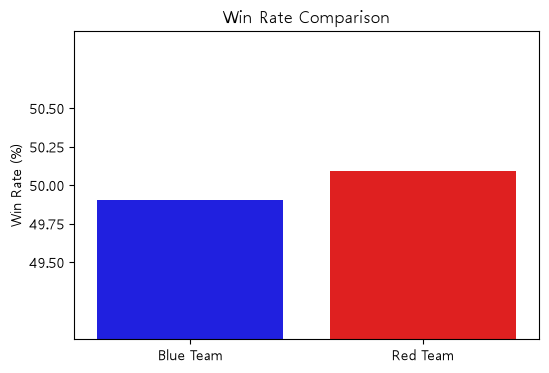

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 승률 계산 
blue_win_rate = df['blueWins'].mean() * 100  # 미세하게 높음
red_win_rate = (1 - df['blueWins'].mean()) * 100   # 미세하게 낮음
teams = ['Blue Team', 'Red Team']
win_rates = [blue_win_rate, red_win_rate]

# 막대그래프 그리기
plt.figure(figsize=(6, 4))
sns.barplot(x=teams, y=win_rates, palette=['blue', 'red'])

# 핵심: Y축 범위를 50% 근처로 좁혀서 차이를 극대화
plt.ylim(49, 51) 

plt.title('Win Rate Comparison')
plt.ylabel('Win Rate (%)')
# Y축 눈금도 더 세밀하게 표시
plt.yticks([49.5, 49.75, 50, 50.25, 50.5])

plt.show()

In [11]:
# X값 y값 설정
factors = ['blueWardsPlaced', 
           'blueWardsDestroyed', 
           'blueFirstBlood', 
           'blueKills', 
           'blueDeaths',
           'blueAssists',
           'blueGoldDiff',
           'blueExperienceDiff'
           ]
X = df[factors]
y = df['blueWins']

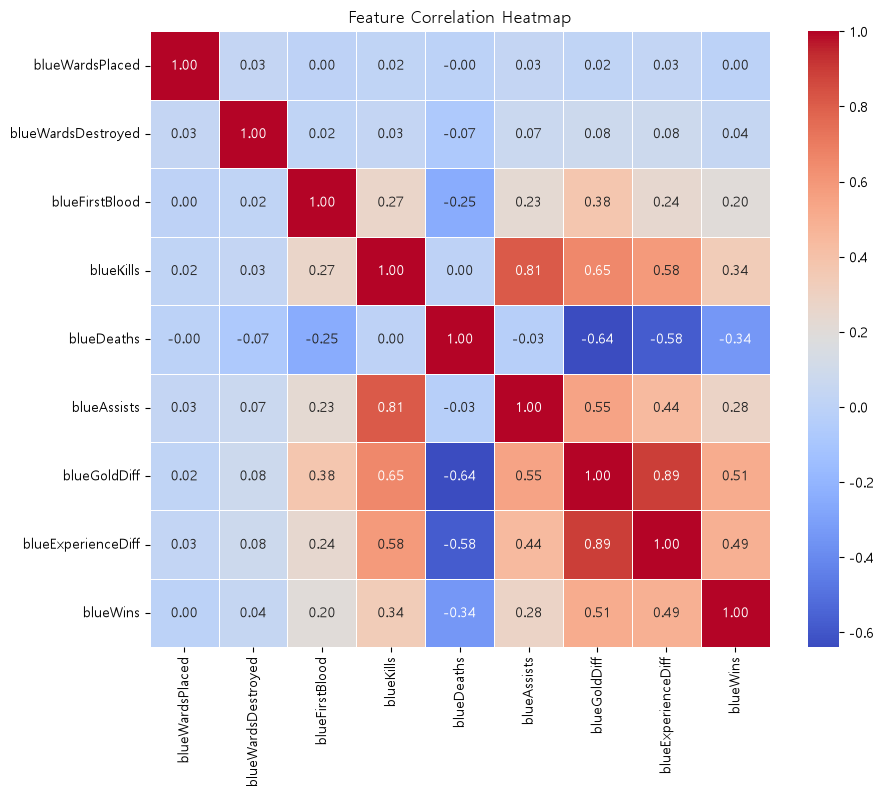

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# X와 y를 합쳐서 전체 상관관계 계산
df_corr = X.copy()
df_corr['blueWins'] = y

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap')
plt.show()

In [13]:
# X와 y를 합친 데이터프레임에서 승패와의 상관관계만 추출 후 내림차순 정렬
df_corr = X.copy()
df_corr['blueWins'] = y

correlation_result = df_corr.corr()['blueWins'].sort_values(ascending=False)
print(correlation_result)

blueWins              1.000000
blueGoldDiff          0.511119
blueExperienceDiff    0.489558
blueKills             0.337358
blueAssists           0.276685
blueFirstBlood        0.201769
blueWardsDestroyed    0.044247
blueWardsPlaced       0.000087
blueDeaths           -0.339297
Name: blueWins, dtype: float64


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_12660\2564737471.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors)


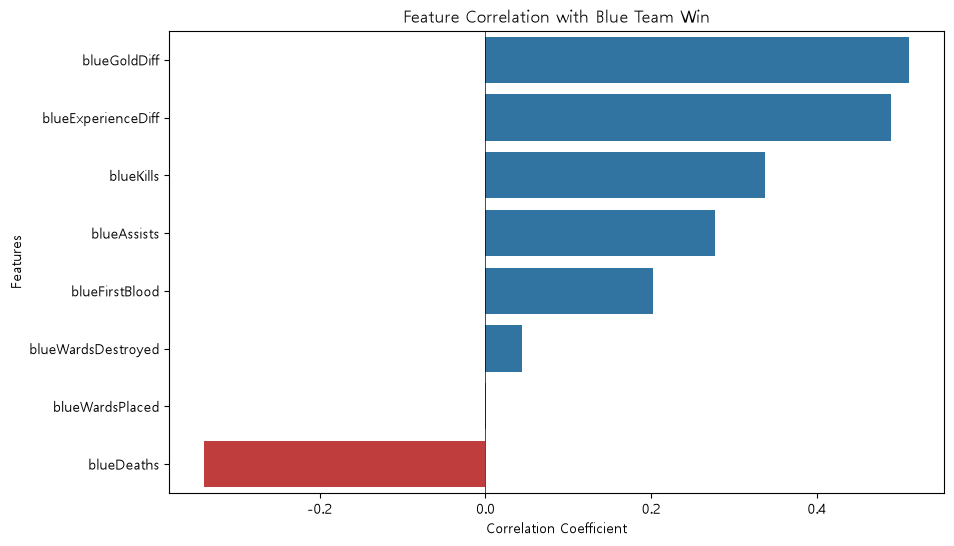

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상관관계 데이터 준비
corr_target = correlation_result.drop('blueWins')

plt.figure(figsize=(10, 6))

# 색상 리스트 생성
colors = ['#1f77b4' if v > 0 else '#d62728' for v in corr_target.values]

# 핵심: x와 y를 명확히 지정하고 데이터프레임 형태나 시리즈로 전달
sns.barplot(x=corr_target.values, y=corr_target.index, palette=colors)

plt.title('Feature Correlation with Blue Team Win')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features') # Y축
plt.axvline(x=0, color='black', linewidth=0.5)

plt.show()

 
 퍼스트블러드는 긍정적인 영향을 준다.       
 

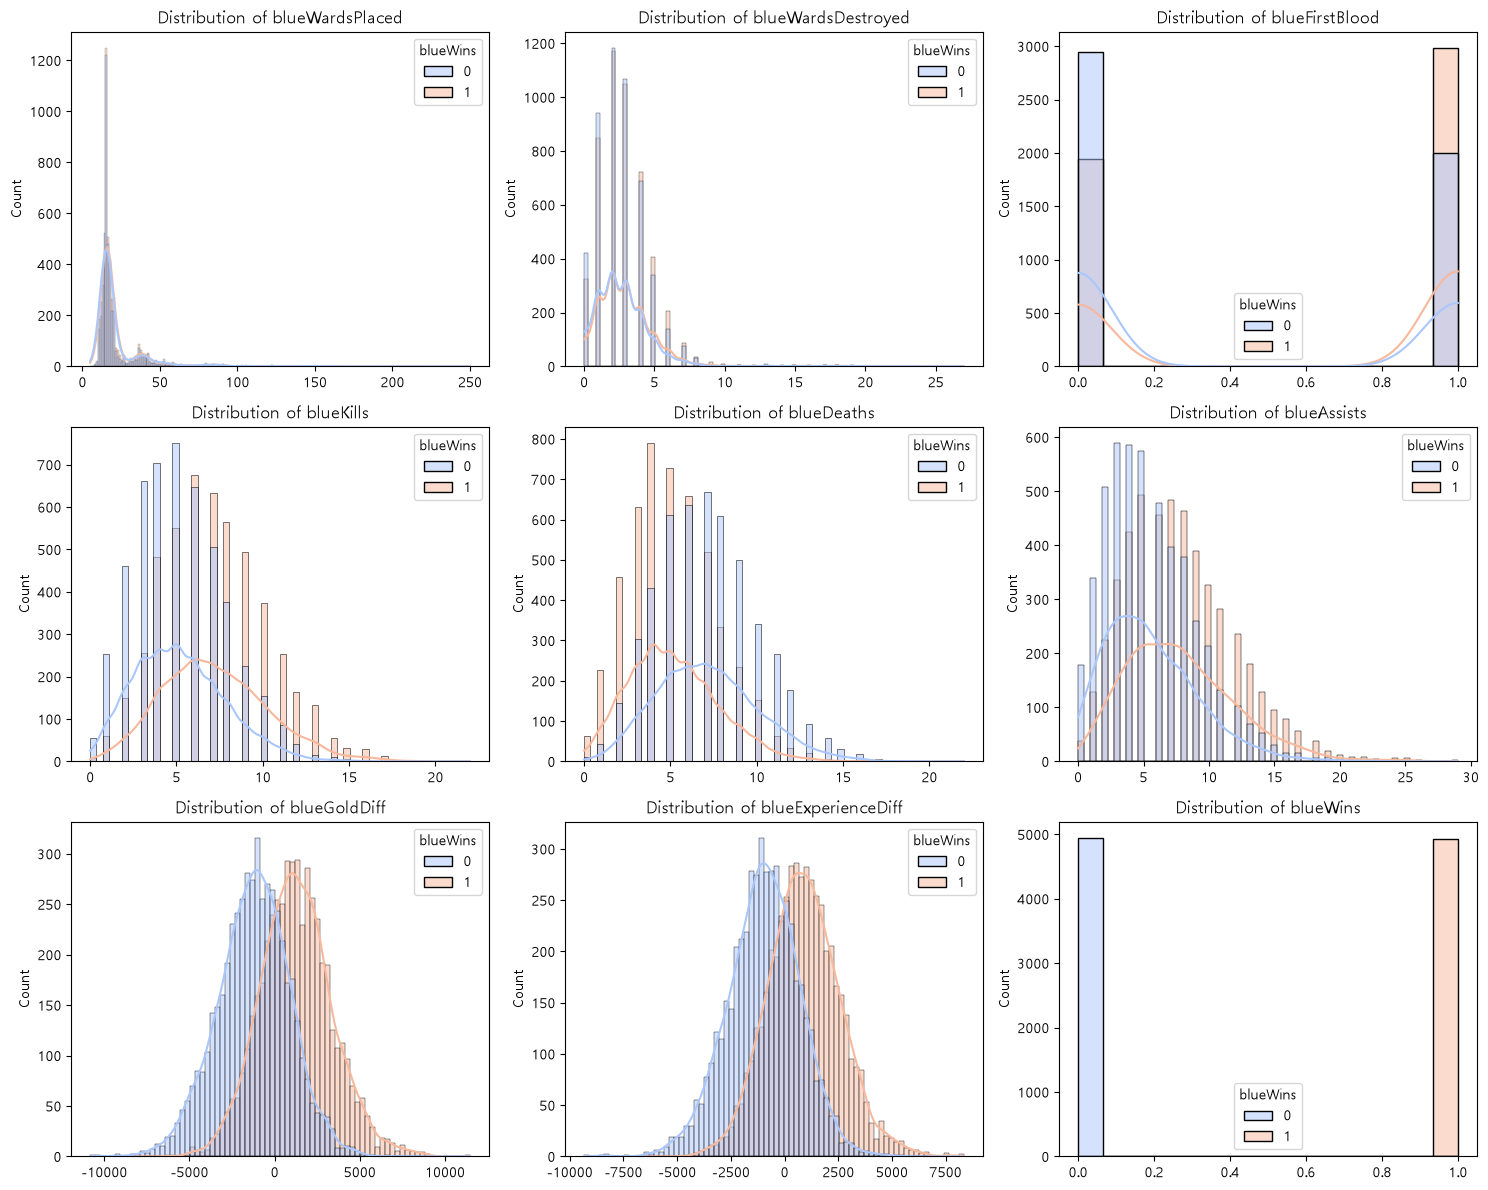

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# X와 y를 합쳐서 전체 데이터프레임 구성
df_eda = X.copy()
df_eda['blueWins'] = y

# 히스토그램을 그릴 컬럼 개수에 맞춰 서브플롯 크기 자동 조절
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

# 각 특성별로 히스토그램 그리기
for i, col in enumerate(df_eda.columns):
    sns.histplot(data=df_eda, x=col, hue='blueWins', kde=True, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

와드 데이터가 좋아보이지 않는다

4. 데이터 전처리
- Feature / Target 분리
- 불필요한 컬럼 제거
- 결측치, 이상치 처리
- 범주형 인코딩, 숫자형 스케일링(스케일링은 데이터 분리 후 진행)
- 학습 데이터 / 테스트 데이터 분리

In [16]:
# 결측치 확인 및 제거 
print(df.isnull().sum())
df = df.dropna()

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

In [17]:
# 와드 관련 컬럼의 기술 통계량 확인 
print(df[['blueWardsPlaced', 'blueWardsDestroyed']].describe())

       blueWardsPlaced  blueWardsDestroyed
count      9879.000000         9879.000000
mean         22.288288            2.824881
std          18.019177            2.174998
min           5.000000            0.000000
25%          14.000000            1.000000
50%          16.000000            3.000000
75%          20.000000            4.000000
max         250.000000           27.000000


In [18]:
# blueWardsPlaced 컬럼을 기준으로 IQR 계산
Q1 = df['blueWardsPlaced'].quantile(0.25)
Q3 = df['blueWardsPlaced'].quantile(0.75)
IQR = Q3 - Q1

# 정상 범위 설정
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 정상 범위 내의 데이터만 남기기 (이상치 컷트)
df = df[(df['blueWardsPlaced'] >= lower_bound) & (df['blueWardsPlaced'] <= upper_bound)]

In [19]:
print(df[['blueWardsPlaced', 'blueWardsDestroyed']].describe())

       blueWardsPlaced  blueWardsDestroyed
count      8252.000000         8252.000000
mean         16.117911            2.786355
std           3.192113            2.159621
min           5.000000            0.000000
25%          14.000000            1.000000
50%          16.000000            2.000000
75%          18.000000            4.000000
max          29.000000           27.000000


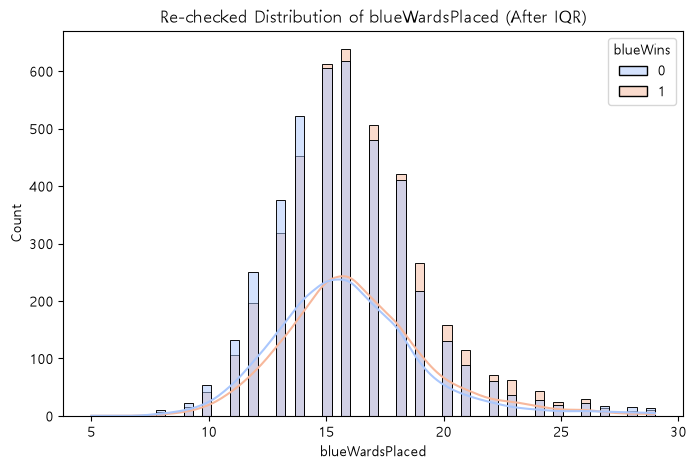

In [20]:

# 이상치 제거 후 와드 설치 개수 분포 재확인
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='blueWardsPlaced', hue='blueWins', kde=True, palette='coolwarm')

plt.title('Re-checked Distribution of blueWardsPlaced (After IQR)')
plt.xlabel('blueWardsPlaced')
plt.show()

In [21]:
# blueWardsDestroyed 컬럼을 기준으로 IQR 계산
Q1_dest = df['blueWardsDestroyed'].quantile(0.25)
Q3_dest = df['blueWardsDestroyed'].quantile(0.75)
IQR_dest = Q3_dest - Q1_dest

# 정상 범위 설정
lower_bound_dest = Q1_dest - 1.5 * IQR_dest
upper_bound_dest = Q3_dest + 1.5 * IQR_dest

# 정상 범위 내의 데이터만 남기기
df = df[(df['blueWardsDestroyed'] >= lower_bound_dest) & (df['blueWardsDestroyed'] <= upper_bound_dest)]

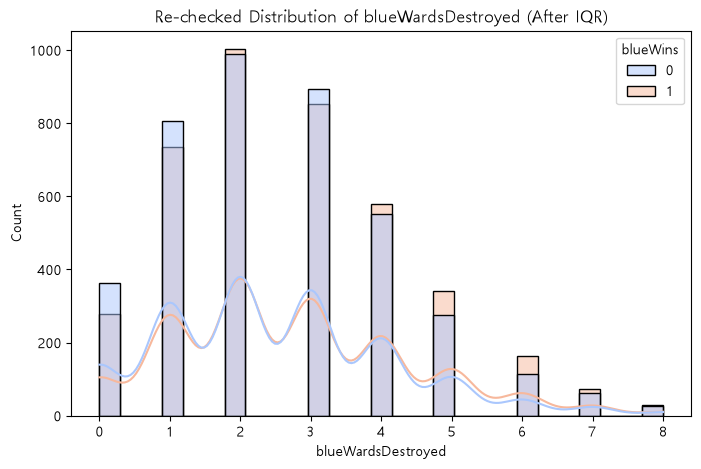

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='blueWardsDestroyed', hue='blueWins', kde=True, palette='coolwarm')

plt.title('Re-checked Distribution of blueWardsDestroyed (After IQR)')
plt.xlabel('blueWardsDestroyed')
plt.show()

5. 모델 불러오기 및 학습

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(len(X_train), len(X_test), len(y_train), len(y_test))

7903 1976 7903 1976


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression

# 모델 선언 
lr = LogisticRegression(random_state=42, max_iter = 1000)

# 학습 데이터로 훈련시키기
lr.fit(X_train_scaled, y_train)

print("학습 완료")

학습 완료


In [26]:
# 2. 예측 및 정확도 확인 
y_pred = lr.predict(X_test_scaled)
print(f"모델 정확도: {accuracy_score(y_test, y_pred):.4f}")
print("\n분류 보고서:\n", classification_report(y_test, y_pred))

모델 정확도: 0.7151

분류 보고서:
               precision    recall  f1-score   support

           0       0.72      0.72      0.72       990
           1       0.71      0.72      0.71       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



학습 데이터셋 정확도 : 0.7284575477666709
학습 데이터셋 정밀도 : 0.7302231237322515
학습 데이터셋 재현율 : 0.7269056032306915
학습 데이터셋 F1-Score : 0.7285605868960283
-------------------
테스트 데이터셋 정확도 : 0.715080971659919
테스트 데이터셋 정밀도 : 0.7150101419878296
테스트 데이터셋 재현율 : 0.7142857142857143
테스트 데이터셋 F1-Score : 0.7146477445514445


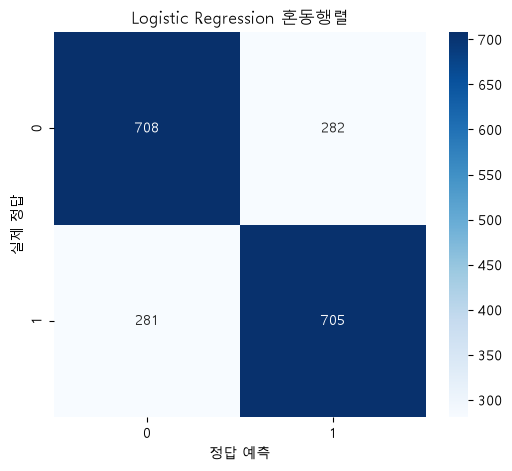

In [27]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# LogisticRegression 모델 정의 및 학습 (반복 1000번)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_train = lr.predict(X_train_scaled)
y_pred = lr.predict(X_test_scaled)

print(f"학습 데이터셋 정확도 : {accuracy_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 정밀도 : {precision_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 재현율 : {recall_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 F1-Score : {f1_score(y_pred_train, y_train)}")
print("-------------------")
print(f"테스트 데이터셋 정확도 : {accuracy_score(y_pred, y_test)}")
print(f"테스트 데이터셋 정밀도 : {precision_score(y_pred, y_test)}")
print(f"테스트 데이터셋 재현율 : {recall_score(y_pred, y_test)}")
print(f"테스트 데이터셋 F1-Score : {f1_score(y_pred, y_test)}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('정답 예측')
plt.ylabel('실제 정답')
plt.title('Logistic Regression 혼동행렬')
plt.show()

Logistic Regression 사용결과 72% 정확도

학습 데이터셋 정확도 : 1.0
학습 데이터셋 정밀도 : 1.0
학습 데이터셋 재현율 : 1.0
학습 데이터셋 F1-Score : 1.0
-------------------
테스트 데이터셋 정확도 : 0.708502024291498
테스트 데이터셋 정밀도 : 0.6957403651115619
테스트 데이터셋 재현율 : 0.7130977130977131
테스트 데이터셋 F1-Score : 0.704312114989733


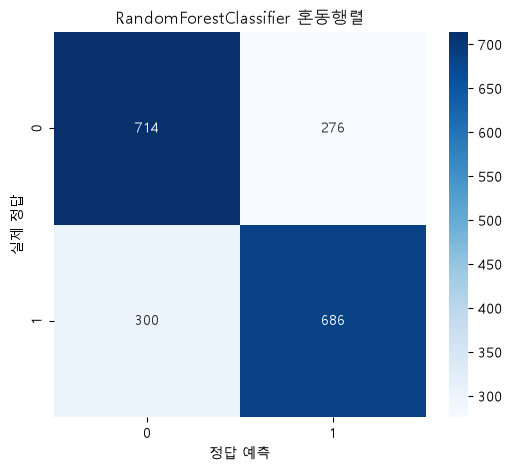

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# RandomForestClassifier 모델 정의 및 학습
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

y_pred_train = rfc.predict(X_train)
y_pred = rfc.predict(X_test)

print(f"학습 데이터셋 정확도 : {accuracy_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 정밀도 : {precision_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 재현율 : {recall_score(y_pred_train, y_train)}")
print(f"학습 데이터셋 F1-Score : {f1_score(y_pred_train, y_train)}")
print("-------------------")
print(f"테스트 데이터셋 정확도 : {accuracy_score(y_pred, y_test)}")
print(f"테스트 데이터셋 정밀도 : {precision_score(y_pred, y_test)}")
print(f"테스트 데이터셋 재현율 : {recall_score(y_pred, y_test)}")
print(f"테스트 데이터셋 F1-Score : {f1_score(y_pred, y_test)}")

# 만약 le(LabelEncoder)를 사용하지 않았다면 labels 변수 처리 필요
# labels = le.classes_ 생략 시 xticklabels와 yticklabels 인자 제거 가능
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('정답 예측')
plt.ylabel('실제 정답')
plt.title('RandomForestClassifier 혼동행렬')
plt.show()

학습지표가 검증지표보다 높게 나옴 과적합 의심.

LogisticRegression 특성 중요도 분석

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. 튜닝할 하이퍼파라미터 후보군 설정 
param_grid = {
    'n_estimators': [50, 100, 200],          # 만들 나무의 개수
    'max_depth': [None, 5, 10, 20],          # 나무의 최대 깊이
    'min_samples_split': [2, 5, 10]          # 노드를 분할하기 위한 최소 샘플 수
}

# 2. 기본 모델 선언
rfc_base = RandomForestClassifier(random_state=42)

# 3. GridSearchCV를 이용해 가장 성능 좋은 조합 탐색 (교차 검증 5폴드)
grid_search = GridSearchCV(
    estimator=rfc_base,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# 4. 학습 데이터로 최적의 조합 탐색 시작
grid_search.fit(X_train_scaled, y_train)

# 5. 결과 확인
print("최적의 하이퍼파라미터:", grid_search.best_params_)
print(f"최적 교차 검증 정확도: {grid_search.best_score_:.4f}")

# 6. 가장 성능이 좋은 최적의 모델을 변수에 담기
best_rfc = grid_search.best_estimator_

최적의 하이퍼파라미터: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
최적 교차 검증 정확도: 0.7285


In [ ]:
import joblib

# 1. 학습된 최적의 모델과 스케일러를 파일로 저장 
joblib.dump(best_rfc, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("모델과 스케일러가 성공적으로 저장되었습니다!")

# 2. 나중에 다시 불러와서 사용할 때 
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')
print("저장된 모델과 스케일러를 불러왔습니다!")

모델과 스케일러가 성공적으로 저장되었습니다!
저장된 모델과 스케일러를 불러왔습니다!


In [35]:
import pandas as pd

def make_inference_pipeline(new_data, scaler, model):
    # 1. 새로운 데이터가 DataFrame 형태인지 확인 후 전처리 적용
    # (학습 때 사용했던 scaler의 평균/분산 기준을 그대로 적용해야 하므로 transform만 사용)
    new_data_scaled = scaler.transform(new_data)

    # 2. 최적의 모델을 이용해 예측 수행
    predictions = model.predict(new_data_scaled)

    # 3. 예측 확률(확신도)도 함께 확인하고 싶을 때
    probabilities = model.predict_proba(new_data_scaled)

    # 결과 보기 쉽게 데이터프레임으로 묶기
    result_df = new_data.copy()
    result_df['Predicted_Label'] = predictions
    result_df['Prediction_Probability'] = [max(prob) for prob in probabilities]

    return result_df

result_df



,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueGoldDiff,blueExperienceDiff,Predicted_Label,Max_Probability
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,0,0.546139
1,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,0,0.524463
2,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,0,0.531408


In [38]:
import pandas as pd
import numpy as np
import joblib

# 1. 저장된 모델과 스케일러 불러오기
loaded_model = joblib.load('best_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# 2. 기존 학습 데이터(X)의 컬럼 구조를 그대로 가져와서 임의의 데이터 3개 생성
np.random.seed(42)
dummy_data = pd.DataFrame(
    np.random.randn(3, len(X.columns)), 
    columns=X.columns
)

print("--- 생성된 임의의 입력 데이터 ---")
print(dummy_data)

# 3. 추론 파이프라인 적용 (스케일링 -> 예측)
dummy_scaled = loaded_scaler.transform(dummy_data)
predictions = loaded_model.predict(dummy_scaled)
probabilities = loaded_model.predict_proba(dummy_scaled)

# 4. 결과 정리 및 출력 
result_df = dummy_data.copy()
result_df['Predicted_Label'] = predictions
result_df['Max_Probability'] = [max(prob) for prob in probabilities]

print("\n--- 최종 추론 결과 ---")
result_df

--- 생성된 임의의 입력 데이터 ---
   blueWardsPlaced  blueWardsDestroyed  blueFirstBlood  blueKills  blueDeaths  \
0         0.496714           -0.138264        0.647689   1.523030   -0.234153   
1        -0.469474            0.542560       -0.463418  -0.465730    0.241962   
2        -1.012831            0.314247       -0.908024  -1.412304    1.465649   

   blueAssists  blueGoldDiff  blueExperienceDiff  
0    -0.234137      1.579213            0.767435  
1    -1.913280     -1.724918           -0.562288  
2    -0.225776      0.067528           -1.424748  

--- 최종 추론 결과 ---


,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueGoldDiff,blueExperienceDiff,Predicted_Label,Max_Probability
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,0,0.546139
1,-0.469474,0.542560,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,0,0.524463
2,-1.012831,0.314247,-0.908024,-1.412304,1.465649,-0.225776,0.067528,-1.424748,0,0.531408
